In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

# Load data and clean it up

In [2]:
# Load the data
df = pd.read_csv("data/training_set_VU_DM.csv")

# add label column
df["label"] = df["booking_bool"] * 5 + (df["click_bool"] & ~df["booking_bool"]) * 1

# add relevant information from date-time, and remove the original date-time column
df['date_time'] = pd.to_datetime(df['date_time'])
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday
df.drop(columns=['date_time'], inplace=True)

# filter unrealstic prices (price_usd)
df = df[(df["price_usd"] >= 10) & (df["price_usd"] <= 1000)]

# filter unrealistic prices for gross_bookings_usd
df = df[(df["gross_bookings_usd"].isna()) | ((df["gross_bookings_usd"] >= 10) & (df["gross_bookings_usd"] <= 2000))]




# Create some new features

In [3]:
# relative expense feature 
df["relative_expense"] = df["price_usd"] / df["visitor_hist_adr_usd"]

# relative quality feature
df["star_rating_diff"] = df["prop_starrating"] - df["visitor_hist_starrating"]


[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.323911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4755
[LightGBM] [Info] Number of data points in the train set: 3948416, number of used features: 52
[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	train's ndcg@5: 0.396967	train's ndcg@5: 0.396967	val's ndcg@5: 0.388729	val's ndcg@5: 0.388729
defaultdict(<class 'collections.OrderedDict'>, {'train': OrderedDict([('ndcg@5', np.float64(0.39696700302356386))]), 'val': OrderedDict([('ndcg@5', np.float64(0.38872

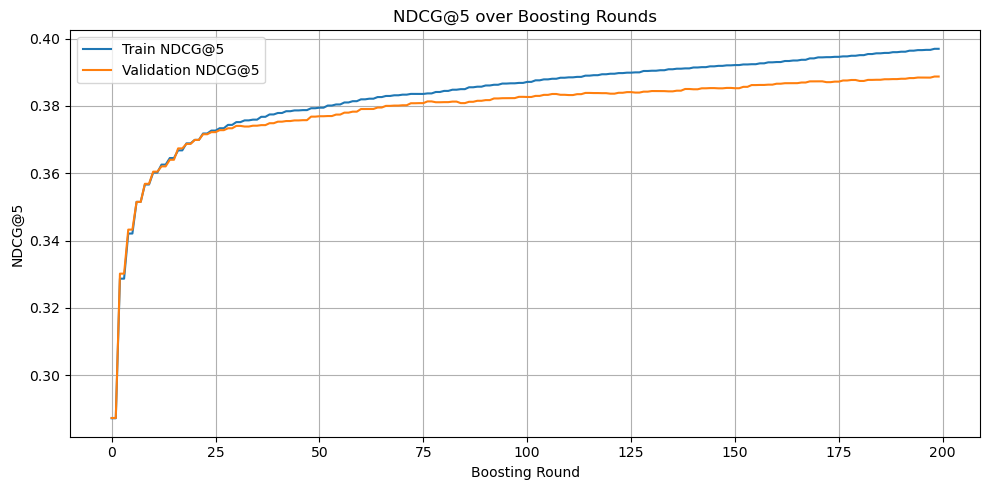

Final NDCG@5 on validation set: 0.38873


In [4]:

# Load data and create ranking label (5 for booking, 1 for clicked but not booked)
df["label"] = df["booking_bool"] * 5 + (df["click_bool"] & ~df["booking_bool"]) * 1

# get all unique search IDs and split into train and val
all_search_ids = df["srch_id"].unique()
train_ids, val_ids = train_test_split(all_search_ids, test_size=0.2, random_state=42)

# filter the full dataframe by train and val search IDs and sort by search ID
train_df = df[df["srch_id"].isin(train_ids)].copy()
val_df   = df[df["srch_id"].isin(val_ids)].copy()
train_df = train_df.sort_values(by="srch_id")
val_df   = val_df.sort_values(by="srch_id")

# create group size lists
group_sizes_train = train_df.groupby("srch_id").size().tolist()
group_sizes_val = val_df.groupby("srch_id").size().tolist()

# check if unwanted columns/features are in df and keep note of the ones that you don't need/want
to_drop = ["srch_id", "label", "position", "click_bool", "booking_bool", "gross_bookings_usd"]
existing_cols = [col for col in to_drop if col in val_df.columns]

# drop unwanted features for train and val sets and add target variable for both
train_x = train_df.drop(columns=existing_cols)
val_x = val_df.drop(columns=existing_cols)
train_y = train_df["label"]
val_y = val_df["label"]

# create rank model
model = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    importance_type="gain",
    early_stopping_rounds=10,
    n_estimators=100,
)

# train the model
model.fit(
    X=train_x,
    y=train_y,
    group=group_sizes_train,
    eval_set=[(train_x, train_y), (val_x, val_y)],
    eval_group=[group_sizes_train, group_sizes_val],
    eval_at=[5, 5],  
    eval_metric="ndcg",
    eval_names=["train", "val"],
)

print(model.best_score_)

# Plot training and validation NDCG@5 over boosting rounds
evals_result = model.evals_result_

plt.figure(figsize=(10, 5))
plt.plot(evals_result["train"]["ndcg@5"], label="Train NDCG@5")
plt.plot(evals_result["val"]["ndcg@5"], label="Validation NDCG@5")
plt.xlabel("Boosting Round")
plt.ylabel("NDCG@5")
plt.title("NDCG@5 over Boosting Rounds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final validation score
final_val_score = evals_result["val"]["ndcg@5"][-1]
print(f"Final NDCG@5 on validation set: {final_val_score:.5f}")



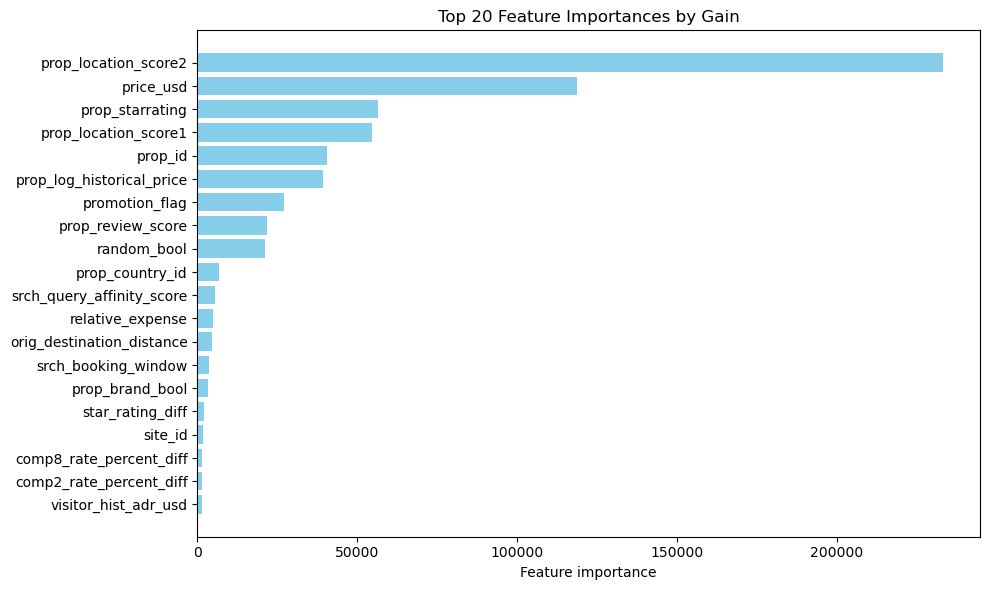

In [5]:

# ✅ Get feature importances (by gain)
importances = model.booster_.feature_importance(importance_type='gain')
feature_names = model.booster_.feature_name()

# ✅ Combine and sort
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(20)

# ✅ Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="skyblue")
plt.xlabel("Feature importance")
plt.title("Top 20 Feature Importances by Gain")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()